# Fine-tune PhoBERT — Vietnamese Sentiment Analysis

**Data**: `stg_comments_labeled.csv` (10,000 comments, 3 classes: negative / neutral / positive)  
**Model base**: `vinai/phobert-base`  
**Runtime**: GPU T4 (Google Colab)

**Trước khi chạy:**
1. `Runtime → Change runtime type → T4 GPU`
2. Upload file `data/stg_comments_labeled.csv` lên Google Drive
3. Chạy từng cell theo thứ tự

## 1. Cài đặt thư viện

In [1]:
# %%capture
# !pip install transformers==4.40.0 datasets accelerate sentencepiece
# !pip install scikit-learn pandas numpy tqdm

In [35]:
!pip install datasets

In [37]:
import pandas as pd
from datasets import load_dataset

# ── Dataset 1: Smartphone reviews tiếng Việt (cùng domain nhất) ──────────────
# anotherpolarbear/vietnamese-sentiment-analysis
# 10k reviews từ trang TGDD, label 1-5 sao → map về 0/1/2
print("Downloading smartphone reviews dataset...")
try:
    ds1 = load_dataset("anotherpolarbear/vietnamese-sentiment-analysis")
    dfs1 = [ds1[s].to_pandas() for s in ds1.keys()]
    df1 = pd.concat(dfs1, ignore_index=True)
    print(f"  Smartphone: {len(df1)} rows | cols: {df1.columns.tolist()}")
    print(f"  Label values: {sorted(df1.iloc[:, -1].unique())}")
except Exception as e:
    print(f"  [WARN] {e}")
    df1 = pd.DataFrame()

# ── Dataset 2: General Vietnamese social media comments ──────────────────────
# minhtoan/vietnamese-comment-sentiment
# 13k comments, label 6 class → gộp về 3
print("Downloading social media comments dataset...")
try:
    ds2 = load_dataset("minhtoan/vietnamese-comment-sentiment")
    dfs2 = [ds2[s].to_pandas() for s in ds2.keys()]
    df2 = pd.concat(dfs2, ignore_index=True)
    print(f"  Social: {len(df2)} rows | cols: {df2.columns.tolist()}")
    print(f"  Label values: {sorted(df2['Sentiment'].unique())}")
except Exception as e:
    print(f"  [WARN] {e}")
    df2 = pd.DataFrame()

print("\nDownload xong ✅")

README.md:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/7786 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2224 [00:00<?, ? examples/s]

  Smartphone: 10010 rows | cols: ['comment', 'label']
  Label values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


README.md: 0.00B [00:00, ?B/s]

vietnamese-comment-sentiment.csv:   0%|          | 0.00/35.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/13132 [00:00<?, ? examples/s]

  Social: 13132 rows | cols: ['ID', 'Title', 'Content', 'BriefContent', 'URL', 'Published Date', 'Week', 'Keyword', 'Group', 'Sub', 'Keyword 2', 'Sentiment', 'Ngành', 'Source', 'Channel', 'Author']
  Label values: ['Tiêu cực', 'Trung lập', 'Tích cực', 'negative', 'neutral', 'positive']

Download xong ✅


## 2. Mount Google Drive & kiểm tra GPU

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

# import torch
# print(f"GPU available : {torch.cuda.is_available()}")
# if torch.cuda.is_available():
#     print(f"GPU name      : {torch.cuda.get_device_name(0)}")
#     print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Mounted at /content/drive
GPU available : True
GPU name      : Tesla T4
VRAM          : 15.6 GB


## 3. Cấu hình — chỉnh ở đây trước khi chạy

In [22]:
import os


DATA_PATH   = "/content/drive/MyDrive/nlp_bd/stg_comments_labeled.csv"
OUTPUT_DIR  = "/content/drive/MyDrive/nlp_bd/models/phobert_finetuned_v2"
CKPT_DIR    = "/content/drive/MyDrive/nlp_bd/models/checkpoints_v2"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,   exist_ok=True)

MODEL_NAME   = "vinai/phobert-base"
NUM_LABELS   = 3
MAX_LENGTH   = 256
BATCH_SIZE   = 16
EVAL_BS      = 32
NUM_EPOCHS   = 5
LR           = 1e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.15
MAX_GRAD_NORM = 1.0
SEED         = 42
PATIENCE     = 2

TRAIN_RATIO  = 0.8

CLASS_WEIGHTS = None


## 4. Load & khám phá dữ liệu

In [54]:
import pandas as pd
import numpy as np

df = pd.read_csv(DATA_PATH)
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Shape  : (10000, 6)
Columns: ['post_id', 'source', 'body', 'label_id', 'sentiment', 'confidence']


,post_id,source,body,label_id,sentiment,confidence
0,vne_347f4622c57d,vnexpress,quá là thần thánh 685 luôn,2,positive,0.80
1,dcc58655546e,voz,đã 2 năm kể từ thời điểm iphone 12 pro max đượ...,2,positive,0.90
2,vne_e55f407c66b4,vnexpress,685 còn yếu hơn cả 675 của redmi note 7 pro nữ...,0,negative,0.95


sentiment
neutral     4281
negative    3585
positive    2134
Name: count, dtype: int64


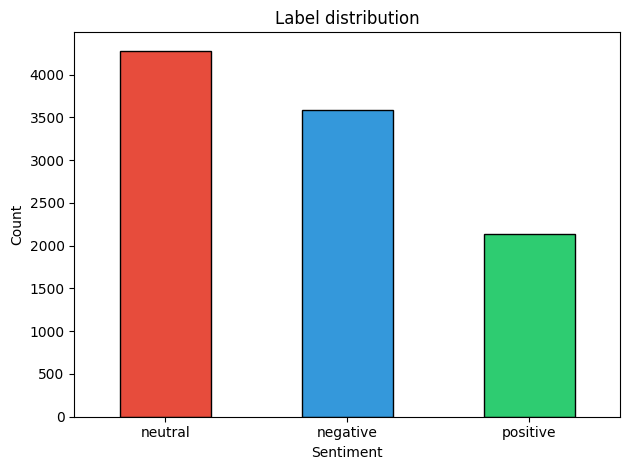


Null values:
body        0
label_id    0
dtype: int64


In [55]:
import matplotlib.pyplot as plt

counts = df['sentiment'].value_counts()
print(counts)

counts.plot(kind='bar', color=['#e74c3c','#3498db','#2ecc71'], edgecolor='black')
plt.title('Label distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Kiểm tra missing
print(f"\nNull values:\n{df[['body','label_id']].isnull().sum()}")

## 5. Tiền xử lý & split data

Trước lọc : 10,000 samples
Sau lọc   : 5,409 samples  (bỏ 4,591 nhãn nhiễu)

Phân phối sau lọc:
  negative  :  2900  (53.6%)
  positive  :  1685  (31.2%)
  neutral   :   824  (15.2%)


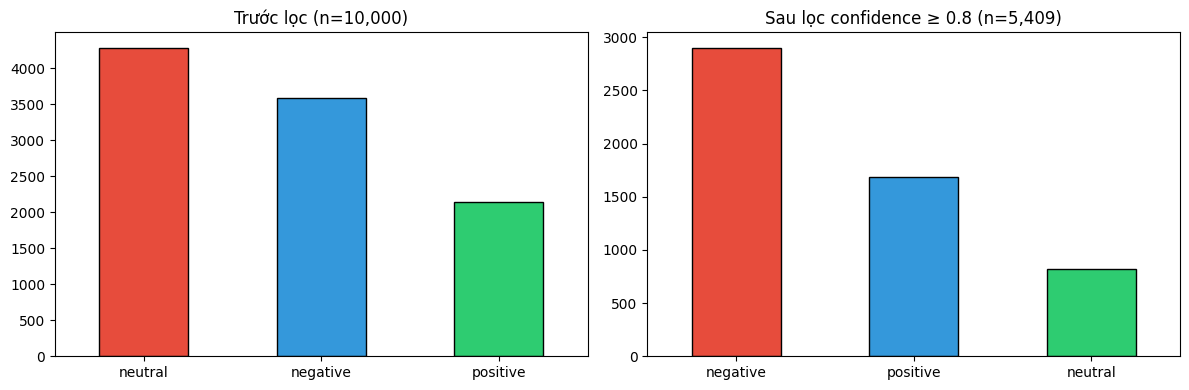

In [56]:

CONFIDENCE_THRESHOLD = 0.8

before = len(df)
df_filtered = df[df['confidence'] >= CONFIDENCE_THRESHOLD].reset_index(drop=True)
after = len(df_filtered)

print(f"Trước lọc : {before:,} samples")
print(f"Sau lọc   : {after:,} samples  (bỏ {before - after:,} nhãn nhiễu)")
print()


dist = df_filtered['sentiment'].value_counts()
print("Phân phối sau lọc:")
for label, count in dist.items():
    print(f"  {label:<10}: {count:5d}  ({count/after*100:.1f}%)")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['sentiment'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#e74c3c','#3498db','#2ecc71'], edgecolor='black')
axes[0].set_title(f'Trước lọc (n={before:,})')
axes[0].set_xlabel(''); axes[0].tick_params(axis='x', rotation=0)

dist.plot(kind='bar', ax=axes[1],
    color=['#e74c3c','#3498db','#2ecc71'], edgecolor='black')
axes[1].set_title(f'Sau lọc confidence ≥ {CONFIDENCE_THRESHOLD} (n={after:,})')
axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

df = df_filtered


In [57]:

# ── Normalize Dataset 1: rating 1-5 → 0/1/2 ─────────────────────────────────
# 1-2 sao = negative, 3 sao = neutral, 4-5 sao = positive
rows_pub = []

if not df1.empty:
    text_col1  = next((c for c in df1.columns if c in ('comment', 'text', 'review', 'content')), df1.columns[0])
    label_col1 = next((c for c in df1.columns if c in ('label', 'rating', 'star', 'sentiment')), df1.columns[-1])
    remap1 = {1: 0, 2: 0, 3: 1, 4: 2, 5: 2}
    df1_norm = pd.DataFrame({
        'body':     df1[text_col1].astype(str),
        'label_id': df1[label_col1].map(remap1),
        'source':   'smartphone_reviews',
    }).dropna()
    df1_norm['label_id'] = df1_norm['label_id'].astype(int)
    # Lấy tối đa 7500 mẫu stratified
    df1_norm = (df1_norm.groupby('label_id', group_keys=False)
                .apply(lambda g: g.sample(min(len(g), round(7000 * len(g) / len(df1_norm))), random_state=SEED))
                .reset_index(drop=True))
    rows_pub.append(df1_norm)
    print(f"Smartphone reviews : {len(df1_norm)} rows")
    print(df1_norm['label_id'].value_counts().rename({0:'neg',1:'neu',2:'pos'}))

# ── Normalize Dataset 2: 6-class → 0/1/2 ────────────────────────────────────
# Tích cực/rất tích cực → positive; Trung lập → neutral; Tiêu cực/rất tiêu cực → negative
if not df2.empty:
    sent_map2 = {}
    for v in df2['Sentiment'].unique():
        v_lower = str(v).lower()
        if any(k in v_lower for k in ['tích cực', 'positive', 'pos']):
            sent_map2[v] = 2
        elif any(k in v_lower for k in ['tiêu cực', 'negative', 'neg']):
            sent_map2[v] = 0
        else:
            sent_map2[v] = 1
    print(f"\nSocial label map: {sent_map2}")

    text_col2 = next((c for c in df2.columns if c in ('Content', 'comment', 'text', 'BriefContent')), 'Content')
    df2_norm = pd.DataFrame({
        'body':     df2[text_col2].astype(str),
        'label_id': df2['Sentiment'].map(sent_map2),
        'source':   'social_comments',
    }).dropna()
    df2_norm['label_id'] = df2_norm['label_id'].astype(int)
    # Lấy tối đa 7500 mẫu stratified
    df2_norm = (df2_norm.groupby('label_id', group_keys=False)
                .apply(lambda g: g.sample(min(len(g), round(7000 * len(g) / len(df2_norm))), random_state=SEED))
                .reset_index(drop=True))
    rows_pub.append(df2_norm)
    print(f"Social comments    : {len(df2_norm)} rows")
    print(df2_norm['label_id'].value_counts().rename({0:'neg',1:'neu',2:'pos'}))

# ── Merge tất cả ─────────────────────────────────────────────────────────────
df_our = pd.DataFrame({
    'body':     df['body'].astype(str),
    'label_id': df['label_id'].astype(int),
    'source':   'gemini_labeled',
})

df_merged = pd.concat([df_our] + rows_pub, ignore_index=True)
df_merged = df_merged[df_merged['body'].str.len() > 0].reset_index(drop=True)

print(f"\n{'='*45}")
print(f"Data ta (confidence≥0.75) : {len(df_our):>6,}")
for r in rows_pub:
    print(f"  + {r['source'].iloc[0]:<25}: {len(r):>6,}")
print(f"Tổng sau merge            : {len(df_merged):>6,}")
print(f"\nPhân phối label:")
print(df_merged['label_id'].value_counts().rename({0:'negative',1:'neutral',2:'positive'}).to_string())

df = df_merged


Smartphone reviews : 7000 rows
label_id
pos    4429
neg    1683
neu     888
Name: count, dtype: int64

Social label map: {'Trung lập': 1, 'Tích cực': 2, 'Tiêu cực': 0, 'neutral': 1, 'positive': 2, 'negative': 0}
Social comments    : 6999 rows
label_id
neu    5061
pos    1819
neg     119
Name: count, dtype: int64

Data ta (confidence≥0.75) :  5,409
  + smartphone_reviews       :  7,000
  + social_comments          :  6,999
Tổng sau merge            : 19,408

Phân phối label:
label_id
positive    7933
neutral     6773
negative    4702


/tmp/ipykernel_5127/2181133584.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), round(7000 * len(g) / len(df1_norm))), random_state=SEED))
/tmp/ipykernel_5127/2181133584.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), round(7000 * len(g) / len(df2_norm))), random_state=SEED))


In [58]:
import re
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

def clean_text(text: str) -> str:
    text = str(text).strip()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^\w\sÀ-ɏḀ-ỿ.,!?;:()\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df = df.dropna(subset=['body', 'label_id']).copy()
df['body'] = df['body'].apply(clean_text)
df = df[df['body'].str.len() > 0].reset_index(drop=True)

texts  = df['body'].tolist()
labels = df['label_id'].astype(int).tolist()

# Split 80/10/10 stratified
X_train, X_tmp, y_train, y_tmp = train_test_split(
    texts, labels, test_size=1 - TRAIN_RATIO, random_state=SEED, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp
)

print(f"Train : {len(X_train)}")
print(f"Val   : {len(X_val)}")
print(f"Test  : {len(X_test)}")

# Tính class weights tự động từ training set
cw = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_train)
CLASS_WEIGHTS = cw.tolist()
print(f"\nClass weights (auto): neg={CLASS_WEIGHTS[0]:.3f} | neu={CLASS_WEIGHTS[1]:.3f} | pos={CLASS_WEIGHTS[2]:.3f}")

Train : 15524
Val   : 1940
Test  : 1941

Class weights (auto): neg=1.376 | neu=0.955 | pos=0.816


## 6. Dataset & DataLoader

In [59]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
        }

print("Loading PhoBERT tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = SentimentDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_ds   = SentimentDataset(X_val,   y_val,   tokenizer, MAX_LENGTH)
test_ds  = SentimentDataset(X_test,  y_test,  tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,  shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=EVAL_BS, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=EVAL_BS, shuffle=False, num_workers=2, pin_memory=True)

print(f"Tokenizer OK ✅  |  Train batches: {len(train_loader)}")

Loading PhoBERT tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Tokenizer OK ✅  |  Train batches: 971


## 7. Khởi tạo model, optimizer, scheduler

In [60]:
from torch import nn
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Seed
import random
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)
model.to(device)

# Weighted loss
class_weights = torch.tensor(CLASS_WEIGHTS, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

# fp16 scaler (dùng API mới, tránh FutureWarning)
scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

print(f"Model params : {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")
print(f"Total steps  : {total_steps}  |  Warmup: {warmup_steps}")

Device: cuda


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model params : 135.0M
Total steps  : 4855  |  Warmup: 728


## 8. Hàm train & evaluate

In [62]:
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def train_epoch(model, loader, optimizer, scheduler, criterion, scaler, device):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc='  Training', leave=False):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbl  = batch['label'].to(device)

        optimizer.zero_grad()
        if scaler:
            with torch.amp.autocast('cuda'):
                out  = model(input_ids=ids, attention_mask=mask)
                loss = criterion(out.logits, lbl)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            out  = model(input_ids=ids, attention_mask=mask)
            loss = criterion(out.logits, lbl)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in tqdm(loader, desc='  Evaluating', leave=False):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbl  = batch['label'].to(device)
        out  = model(input_ids=ids, attention_mask=mask)
        loss = criterion(out.logits, lbl)
        preds = out.logits.argmax(dim=-1)
        total_loss  += loss.item()
        all_preds   += preds.cpu().tolist()
        all_labels  += lbl.cpu().tolist()
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return {
        'loss':     total_loss / len(loader),
        'accuracy': acc,
        'macro_f1': f1,
        'preds':    all_preds,
        'labels':   all_labels,
    }

print("Functions defined ")

Functions defined 


## 9. Training loop

In [63]:
import json

best_f1         = 0.0
best_ckpt       = None
history         = []
no_improve      = 0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n{'='*55}")
    print(f"Epoch {epoch}/{NUM_EPOCHS}")

    train_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion, scaler, device)
    val_m      = evaluate(model, val_loader, criterion, device)

    row = {
        'epoch':        epoch,
        'train_loss':   round(train_loss, 4),
        'val_loss':     round(val_m['loss'], 4),
        'val_accuracy': round(val_m['accuracy'], 4),
        'val_macro_f1': round(val_m['macro_f1'], 4),
    }
    history.append(row)
    print(f"  Train Loss : {row['train_loss']}")
    print(f"  Val Loss   : {row['val_loss']}")
    print(f"  Val Acc    : {row['val_accuracy']}")
    print(f"  Val F1     : {row['val_macro_f1']}")

    if val_m['macro_f1'] > best_f1:
        best_f1    = val_m['macro_f1']
        best_ckpt  = os.path.join(CKPT_DIR, f"epoch_{epoch}_f1_{best_f1:.4f}")
        model.save_pretrained(best_ckpt)
        tokenizer.save_pretrained(best_ckpt)
        no_improve = 0
        print(f"  ✅ Best saved → {best_ckpt}")
    else:
        no_improve += 1
        print(f"  No improvement ({no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print(f"\n⏹ Early stopping tại epoch {epoch}")
            break

with open(os.path.join(OUTPUT_DIR, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)

print(f"\nTraining done! Best Val F1 = {best_f1:.4f}")


Epoch 1/5


  Training:   0%|          | 0/971 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/61 [00:00<?, ?it/s]

  Train Loss : 0.7489
  Val Loss   : 0.5741
  Val Acc    : 0.7804
  Val F1     : 0.7764
  ✅ Best saved → /content/drive/MyDrive/nlp_bd/models/checkpoints_v2/epoch_1_f1_0.7764

Epoch 2/5


  Training:   0%|          | 0/971 [00:00<?, ?it/s]

...

  Evaluating:   0%|          | 0/61 [00:00<?, ?it/s]

  Train Loss : 0.344
  Val Loss   : 0.547
  Val Acc    : 0.7969
  Val F1     : 0.7914
  ✅ Best saved → /content/drive/MyDrive/nlp_bd/models/checkpoints_v2/epoch_4_f1_0.7914

Epoch 5/5


  Training:   0%|          | 0/971 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/61 [00:00<?, ?it/s]

  Train Loss : 0.3001
  Val Loss   : 0.564
  Val Acc    : 0.7969
  Val F1     : 0.7918
  ✅ Best saved → /content/drive/MyDrive/nlp_bd/models/checkpoints_v2/epoch_5_f1_0.7918

Training done! Best Val F1 = 0.7918


## 10. Đánh giá trên Test set

In [64]:
from transformers import AutoModelForSequenceClassification

print(f"Loading best checkpoint: {best_ckpt}")
best_model = AutoModelForSequenceClassification.from_pretrained(best_ckpt).to(device)
test_m     = evaluate(best_model, test_loader, criterion, device)

print(f"\n{'='*55}")
print(f"Test Accuracy : {test_m['accuracy']:.4f}")
print(f"Test Macro-F1 : {test_m['macro_f1']:.4f}")
print(f"\n{classification_report(test_m['labels'], test_m['preds'], target_names=['Negative','Neutral','Positive'], zero_division=0)}")
cm = confusion_matrix(test_m['labels'], test_m['preds'])
print(f"Confusion Matrix:\n{cm}")

Loading best checkpoint: /content/drive/MyDrive/nlp_bd/models/checkpoints_v2/epoch_5_f1_0.7918


  Evaluating:   0%|          | 0/61 [00:00<?, ?it/s]


Test Accuracy : 0.8073
Test Macro-F1 : 0.7997

              precision    recall  f1-score   support

    Negative       0.74      0.76      0.75       471
     Neutral       0.82      0.81      0.81       677
    Positive       0.84      0.84      0.84       793

    accuracy                           0.81      1941
   macro avg       0.80      0.80      0.80      1941
weighted avg       0.81      0.81      0.81      1941

Confusion Matrix:
[[358  51  62]
 [ 68 545  64]
 [ 61  68 664]]


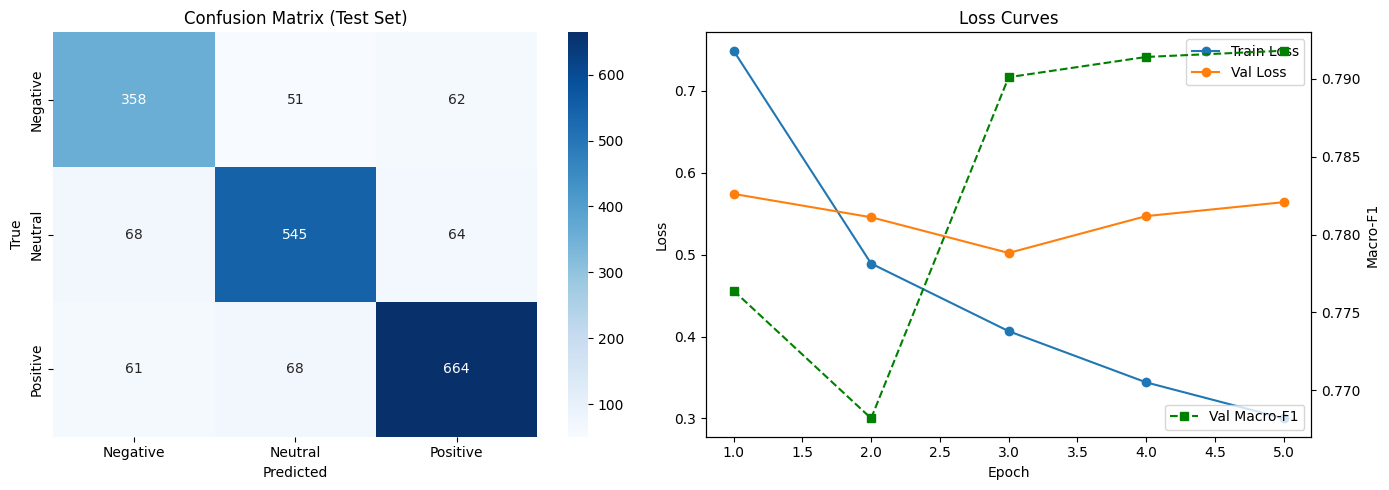

In [65]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Test Set)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Training curves
epochs = [r['epoch']        for r in history]
tl     = [r['train_loss']   for r in history]
vl     = [r['val_loss']     for r in history]
vf1    = [r['val_macro_f1'] for r in history]

ax2 = axes[1]
ax2.plot(epochs, tl,  marker='o', label='Train Loss')
ax2.plot(epochs, vl,  marker='o', label='Val Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_title('Loss Curves')
ax2.legend()

ax3 = ax2.twinx()
ax3.plot(epochs, vf1, marker='s', color='green', linestyle='--', label='Val Macro-F1')
ax3.set_ylabel('Macro-F1')
ax3.legend(loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=120)
plt.show()

## 11. Lưu final model

In [66]:
final_path = os.path.join(OUTPUT_DIR, 'final')
best_model.save_pretrained(final_path)
tokenizer.save_pretrained(final_path)

# Lưu eval results
eval_result = {
    'best_checkpoint':  best_ckpt,
    'best_val_macro_f1': best_f1,
    'test_accuracy':    test_m['accuracy'],
    'test_macro_f1':    test_m['macro_f1'],
    'test_report':      classification_report(
        test_m['labels'], test_m['preds'],
        target_names=['Negative','Neutral','Positive'],
        zero_division=0
    ),
    'test_confusion_matrix': cm.tolist(),
    'training_history': history,
}
with open(os.path.join(OUTPUT_DIR, 'eval_results.json'), 'w') as f:
    json.dump(eval_result, f, indent=2, ensure_ascii=False)

print(f"Final model → {final_path}")
print(f"Eval results → {OUTPUT_DIR}/eval_results.json")
print("Done ✅")

Final model → /content/drive/MyDrive/nlp_bd/models/phobert_finetuned_v2/final
Eval results → /content/drive/MyDrive/nlp_bd/models/phobert_finetuned_v2/eval_results.json
Done ✅


## 12. Quick inference test

In [67]:
LABEL_MAP = {0: 'negative', 1: 'neutral', 2: 'positive'}

def predict(text: str, model, tokenizer, device, max_len=256):
    model.eval()
    enc = tokenizer(
        text, max_length=max_len, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    with torch.no_grad():
        out   = model(enc['input_ids'].to(device), enc['attention_mask'].to(device))
        probs = torch.softmax(out.logits, dim=-1).cpu().numpy()[0]
    lid = int(probs.argmax())
    return {'label': LABEL_MAP[lid], 'label_id': lid, 'confidence': float(probs[lid]),
            'probs': {'negative': float(probs[0]), 'neutral': float(probs[1]), 'positive': float(probs[2])}}

samples = [
    "Điện thoại này quá tệ, pin yếu, lag liên tục!",
    "Máy bình thường, không có gì đặc biệt.",
    "Siêu phẩm! Camera chụp đẹp, hiệu năng mạnh!",
    "685 còn yếu hơn cả 675 của redmi note 7 pro",
    "quá là thần thánh 685 luôn",
]

print(f"{'Text':<50} {'Label':<10} {'Conf':>6}")
print('-' * 70)
for s in samples:
    r = predict(s, best_model, tokenizer, device)
    print(f"{s[:48]:<50} {r['label']:<10} {r['confidence']:>6.2f}")

Text                                               Label        Conf
----------------------------------------------------------------------
Điện thoại này quá tệ, pin yếu, lag liên tục!      negative     0.96
Máy bình thường, không có gì đặc biệt.             neutral      0.63
Siêu phẩm! Camera chụp đẹp, hiệu năng mạnh!        positive     0.99
685 còn yếu hơn cả 675 của redmi note 7 pro        negative     0.98
quá là thần thánh 685 luôn                         positive     0.81
